<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB16(14).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 14

In [ ]:
!pip install transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# --- Complaint emails ---
complaints = [
    "My order arrived broken and damaged I want a refund immediately",
    "This product stopped working after one day I am very disappointed",
    "I have been waiting three weeks and still no delivery this is unacceptable",
    "The customer service was rude and unhelpful I am extremely frustrated",
    "I received the wrong item and nobody is responding to my emails",
    "This is the worst purchase I have ever made total waste of money",
    "My package was lost and no one is helping me fix this problem",
    "The product quality is terrible and nothing like the description",
    "I want to cancel my order immediately this service is horrible",
    "Your company has wasted my time and money I need this resolved now",
    "The item broke on the first use and I want my money back",
    "I have called support five times and still no solution to my problem",
    "This product is defective and dangerous please issue a refund",
    "Very unhappy with the poor quality of this product I am angry",
    "The delivery was extremely late and the package was damaged badly",
    "I expected much better quality this is completely unacceptable",
    "Stop ignoring my emails I need a replacement or refund urgently",
    "The product does not work at all and I feel cheated and angry",
]

# --- Request emails ---
requests = [
    "Could you please send me the invoice for my recent order",
    "I would like to change my delivery address for order number 1234",
    "Please update my account email to the new address I provided",
    "Can you tell me the estimated delivery date for my package",
    "I would like to upgrade my subscription to the premium plan",
    "Could you please provide more details about the warranty policy",
    "I need help resetting my password for my account please",
    "Please cancel my subscription and confirm the cancellation",
    "Can I return this item and get store credit instead of refund",
    "I would like to know if this product is available in blue color",
    "Could you please resend the confirmation email for my order",
    "I need a copy of my purchase history for the last six months",
    "Please help me track my current order it shows no updates",
    "Can you extend my free trial period by another week please",
    "I would like to speak with a manager about my account please",
    "Could you clarify the return policy for international orders",
    "Please add a gift message to my order before it is shipped",
    "Can you confirm whether the item is still in stock for me",
]

# --- Appreciation emails ---
appreciations = [
    "Thank you so much your customer service team was absolutely amazing",
    "I am really happy with my purchase the quality exceeded expectations",
    "The delivery was super fast and the product is exactly as described",
    "Your support team resolved my issue quickly I am very satisfied",
    "Wonderful experience shopping with you I will definitely come back",
    "The product is fantastic and the packaging was very neat and careful",
    "I love this item so much it is perfect and exactly what I needed",
    "Thank you for the quick refund I really appreciate your help today",
    "Best customer service I have experienced in a very long time",
    "I am very impressed with the quality and fast shipping thank you",
    "Your team went above and beyond to help me I really appreciate it",
    "The product works perfectly and arrived earlier than expected great",
    "I am completely satisfied with my order everything was just perfect",
    "Thank you for the wonderful gift wrapping it was a lovely surprise",
    "Your service is outstanding and I have recommended you to my friends",
    "I cannot believe how fast and efficiently my issue was resolved today",
    "Really pleased with the quality and will definitely order again soon",
    "Amazing product great value for money I am one very happy customer",
]

# Combine all
texts  = complaints + requests + appreciations
labels = ([0]*len(complaints) +
          [1]*len(requests) +
          [2]*len(appreciations))

CLASS_NAMES = ["Complaint", "Request", "Appreciation"]

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total emails  : {len(df)}")
print(f"Complaints    : {sum(df.label==0)}")
print(f"Requests      : {sum(df.label==1)}")
print(f"Appreciations : {sum(df.label==2)}")
print("\nSample:")
print(df.head(6)[["text","label"]].to_string())

Total emails  : 54
Complaints    : 18
Requests      : 18
Appreciations : 18

Sample:
                                                                  text  label
0     I would like to change my delivery address for order number 1234      1
1   Thank you for the wonderful gift wrapping it was a lovely surprise      2
2  I am completely satisfied with my order everything was just perfect      2
3        This product is defective and dangerous please issue a refund      0
4         Best customer service I have experienced in a very long time      2
5     This is the worst purchase I have ever made total waste of money      0


In [ ]:
VOCAB_SIZE = 3000
MAX_LEN    = 30
EMBED_DIM  = 64

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

sequences = tokenizer.texts_to_sequences(df["text"])
padded    = pad_sequences(sequences, maxlen=MAX_LEN,
                           padding='post', truncating='post')

X = padded
y = tf.keras.utils.to_categorical(df["label"], num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["label"]
)

print(f"Vocabulary size : {len(tokenizer.word_index)}")
print(f"X_train shape   : {X_train.shape}")
print(f"X_test  shape   : {X_test.shape}")

Vocabulary size : 251
X_train shape   : (43, 30)
X_test  shape   : (11, 30)


In [ ]:
# Custom Transformer Encoder block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, **kwargs):
        super().__init__(**kwargs)
        # Multi-head self-attention
        self.att     = layers.MultiHeadAttention(
                           num_heads=num_heads,
                           key_dim=embed_dim // num_heads)
        # Feed forward network
        self.ffn     = models.Sequential([
                           layers.Dense(ff_dim, activation='relu'),
                           layers.Dense(embed_dim)
                       ])
        # Layer normalisation (stabilises training)
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.drop1   = layers.Dropout(0.1)
        self.drop2   = layers.Dropout(0.1)

    def call(self, x, training=False):
        # Self-attention: each word attends to all other words
        attn_out = self.att(x, x)
        attn_out = self.drop1(attn_out, training=training)
        x        = self.norm1(x + attn_out)   # residual connection

        # Feed forward
        ffn_out  = self.ffn(x)
        ffn_out  = self.drop2(ffn_out, training=training)
        x        = self.norm2(x + ffn_out)    # residual connection
        return x

print("TransformerBlock defined!")

TransformerBlock defined!


In [ ]:
def build_transformer():
    inputs = tf.keras.Input(shape=(MAX_LEN,))

    # Step 1: Embedding (word → dense vector)
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM,
                          input_length=MAX_LEN)(inputs)

    # Step 2: Transformer block (self-attention)
    x = TransformerBlock(embed_dim=EMBED_DIM,
                          num_heads=4,
                          ff_dim=128)(x)

    # Step 3: Pool across all positions
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)

    # Step 4: Classify into 3 classes
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

transformer = build_transformer()
transformer.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,827 (897.76 KB)

 Trainable params: 229,827 (897.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True
)

history = transformer.fit(
    X_train, y_train,
    epochs=60,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nStopped at epoch: {len(history.history['loss'])}")
print(f"Best val accuracy: "
      f"{max(history.history['val_accuracy']):.2%}")

Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.2778 - loss: 1.3019 - val_accuracy: 0.2857 - val_loss: 1.1072
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2778 - loss: 1.1554 - val_accuracy: 0.4286 - val_loss: 1.2093
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 1.0421 - val_accuracy: 0.2857 - val_loss: 1.2880
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4444 - loss: 1.1752 - val_accuracy: 0.1429 - val_loss: 1.2093
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6389 - loss: 0.8962 - val_accuracy: 0.4286 - val_loss: 1.1308
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5556 - loss: 0.9131 - val_accuracy: 0.7143 - val_loss: 0.9263
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 0.7940 - val_accuracy: 0.7143 - val_loss: 0.9087
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.7339 - val_accuracy: 0.4286 - val_loss: 1.0392
E

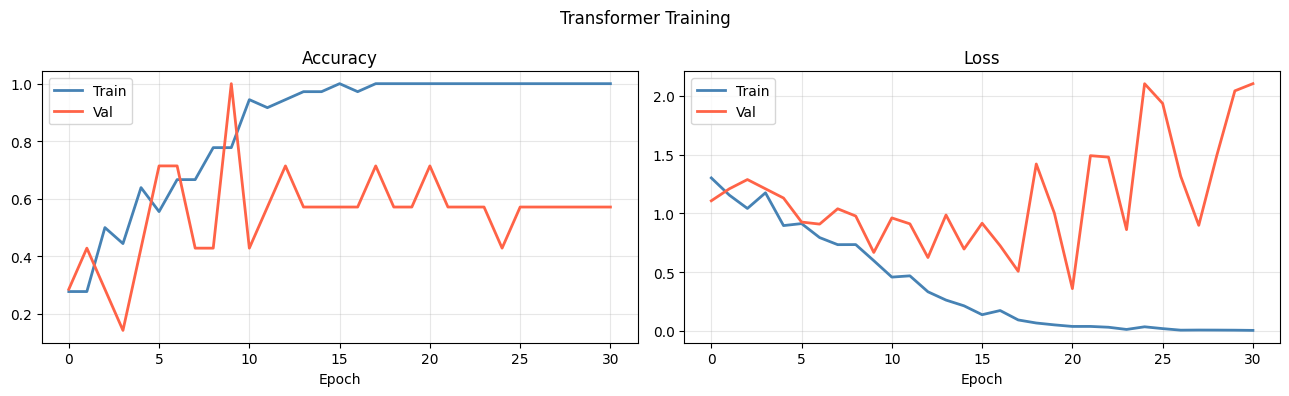

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],
         color='steelblue', linewidth=2, label='Train')
ax1.plot(history.history['val_accuracy'],
         color='tomato',    linewidth=2, label='Val')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],
         color='steelblue', linewidth=2, label='Train')
ax2.plot(history.history['val_loss'],
         color='tomato',    linewidth=2, label='Val')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Transformer Training', fontsize=12)
plt.tight_layout(); plt.show()

Test Accuracy : 72.73%
Test Loss     : 0.9516

              precision    recall  f1-score   support

   Complaint       0.50      1.00      0.67         3
     Request       1.00      1.00      1.00         4
Appreciation       1.00      0.25      0.40         4

    accuracy                           0.73        11
   macro avg       0.83      0.75      0.69        11
weighted avg       0.86      0.73      0.69        11



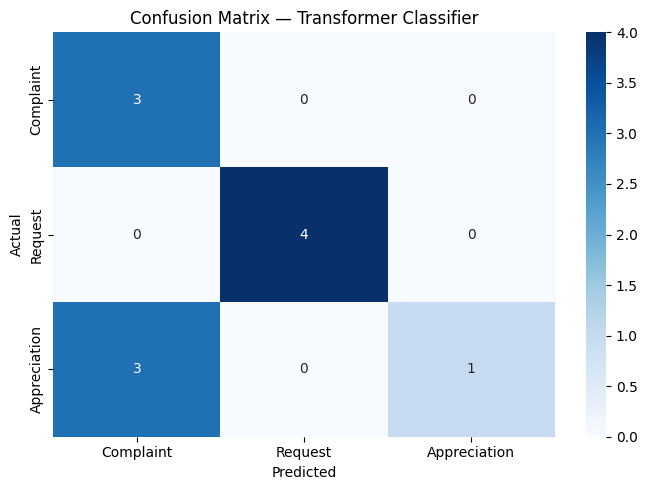

In [ ]:
loss, acc = transformer.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {acc:.2%}")
print(f"Test Loss     : {loss:.4f}\n")

y_pred  = transformer.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred,  axis=1)
y_true_classes = np.argmax(y_test,  axis=1)

print(classification_report(y_true_classes, y_pred_classes,
                             target_names=CLASS_NAMES))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Transformer Classifier')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

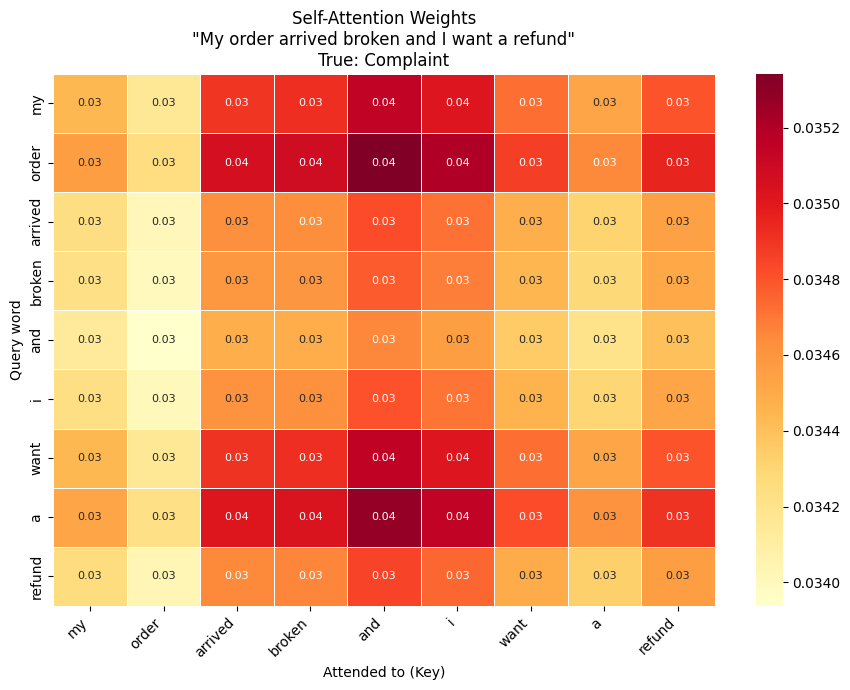

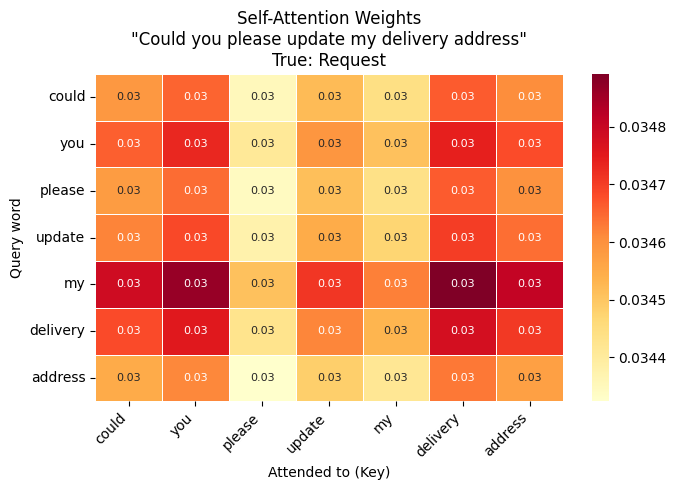

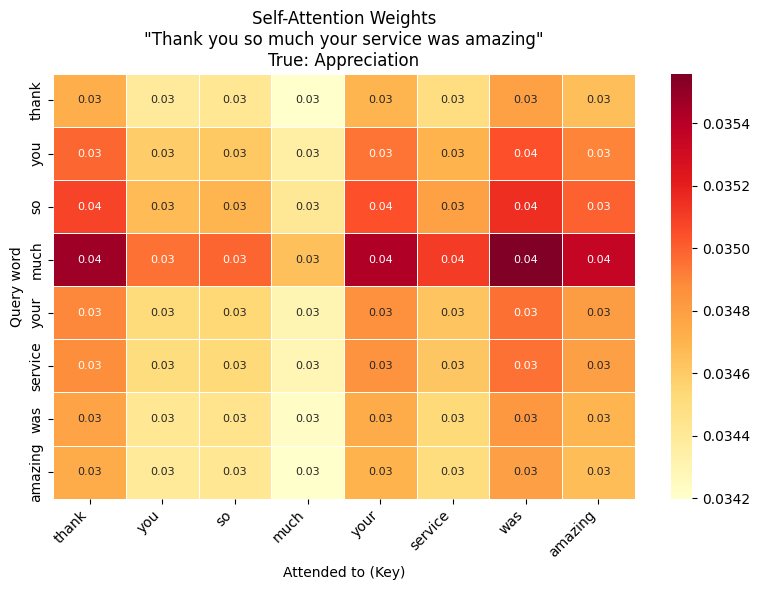

In [ ]:
# Build a model that outputs attention weights
attn_model = tf.keras.Model(
    inputs  = transformer.input,
    outputs = transformer.layers[2].att(
                  transformer.layers[1].output,
                  transformer.layers[1].output,
                  return_attention_scores=True
              )[1]   # [1] = attention scores
)

def plot_attention(text, true_label):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN,
                        padding='post', truncating='post')

    # Get attention weights shape: (1, heads, seq, seq)
    attn_weights = attn_model.predict(pad, verbose=0)

    # Average across all 4 heads
    avg_attn = attn_weights[0].mean(axis=0)   # (MAX_LEN, MAX_LEN)

    # Get actual words (non-padding tokens)
    words   = text.lower().split()[:MAX_LEN]
    n_words = len(words)
    attn_crop = avg_attn[:n_words, :n_words]

    plt.figure(figsize=(max(6, n_words), max(5, n_words-2)))
    sns.heatmap(attn_crop,
                xticklabels=words,
                yticklabels=words,
                cmap='YlOrRd', linewidths=0.5,
                annot=True, fmt='.2f', annot_kws={"size": 8})
    plt.title(f'Self-Attention Weights\n"{text[:60]}"\nTrue: {true_label}')
    plt.xlabel('Attended to (Key)')
    plt.ylabel('Query word')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()

# Show attention for one email of each class
examples = [
    ("My order arrived broken and I want a refund",     "Complaint"),
    ("Could you please update my delivery address",     "Request"),
    ("Thank you so much your service was amazing",      "Appreciation"),
]
for txt, lbl in examples:
    plot_attention(txt, lbl)

In [ ]:
def classify_email(text):
    seq  = tokenizer.texts_to_sequences([text])
    pad  = pad_sequences(seq, maxlen=MAX_LEN,
                          padding='post', truncating='post')
    prob = transformer.predict(pad, verbose=0)[0]
    pred = CLASS_NAMES[np.argmax(prob)]

    print(f"Email   : {text}")
    print(f"Result  : {pred}")
    print(f"Scores  → Complaint:{prob[0]:.2%}  "
          f"Request:{prob[1]:.2%}  "
          f"Appreciation:{prob[2]:.2%}")
    print("-" * 60)

# Test with your own emails!
test_emails = [
    "I am really unhappy my product is broken please help",
    "Can you please tell me when my order will arrive",
    "Wonderful service thank you so much for your help",
    "This is completely unacceptable I want my money back",
    "Please change my subscription plan to the basic tier",
]

for email in test_emails:
    classify_email(email)

Email   : I am really unhappy my product is broken please help
Result  : Complaint
Scores  → Complaint:59.95%  Request:9.12%  Appreciation:30.93%
------------------------------------------------------------
Email   : Can you please tell me when my order will arrive
Result  : Request
Scores  → Complaint:7.31%  Request:91.09%  Appreciation:1.60%
------------------------------------------------------------
Email   : Wonderful service thank you so much for your help
Result  : Appreciation
Scores  → Complaint:1.46%  Request:1.34%  Appreciation:97.19%
------------------------------------------------------------
Email   : This is completely unacceptable I want my money back
Result  : Complaint
Scores  → Complaint:99.80%  Request:0.10%  Appreciation:0.10%
------------------------------------------------------------
Email   : Please change my subscription plan to the basic tier
Result  : Request
Scores  → Complaint:12.43%  Request:87.16%  Appreciation:0.41%
-------------------------------------